# 06_model_training

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import json
import joblib
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve, 
    confusion_matrix
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.base import clone

In [2]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = RESULTS_DIR / "models"
LOGS_DIR = RESULTS_DIR / "logs"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

d:\360Downloads\bioinformatics\Task\AIP


## 1.选择特征集

In [ ]:
# 先做全特征+PCA的，其余同理
FEATURE_SET = "handcrafted_prott5"

In [3]:
FEATURE_SET = "prott5_esm2"
FEATURE_PATH = DATA_DIR / "fusion_selected" / FEATURE_SET

print("当前特征集:", FEATURE_SET)
print("路径:", FEATURE_PATH)

当前特征集: prott5_esm2
路径: d:\360Downloads\bioinformatics\Task\AIP\data\processed\fusion_selected\prott5_esm2


In [4]:
X_train = np.load(FEATURE_PATH / "X_train.npy")
X_test = np.load(FEATURE_PATH / "X_test.npy")
y_train = np.load(FEATURE_PATH / "y_train.npy")
y_test = np.load(FEATURE_PATH / "y_test.npy")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3583, 1248)
X_test: (897, 1248)
y_train: (3583,)
y_test: (897,)


In [5]:
from sklearn.metrics import confusion_matrix

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0


def compute_metrics(y_true, y_pred, y_prob):
    metrics = {
        "ACC": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }
    return metrics

def print_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)

In [6]:
# 调参+阈值优化
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.base import clone

def tune_and_evaluate_model_no_threshold(
    model,
    param_distributions,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name,
    n_iter=20,
    cv_splits=5,
    scoring="average_precision",
    random_state=42
):
    """
    只做参数搜索，不做阈值优化
    最终测试集使用默认阈值 0.5
    """

    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    # ---------- Step 1: 参数搜索 ----------
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=skf,
        n_jobs=-1,
        refit=True,
        random_state=random_state,
        verbose=1
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    print(f"\n===== {model_name} Best Params =====")
    print(search.best_params_)
    print(f"Best CV {scoring}: {search.best_score_:.4f}")

    # ---------- Step 2: 用最佳模型拟合全训练集 ----------
    final_model = clone(best_model)
    final_model.fit(X_train, y_train)

    # ---------- Step 3: 独立测试集评估（默认阈值0.5） ----------
    y_test_prob = final_model.predict_proba(X_test)[:, 1]
    y_test_pred = final_model.predict(X_test)   # 默认就是 0.5 阈值

    test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)

    print(f"\n===== {model_name} Independent Test @ threshold=0.5 =====")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")

    return {
        "search": search,
        "best_model": best_model,
        "final_model": final_model,
        "test_metrics": test_metrics,
        "y_test_prob": y_test_prob,
        "y_test_pred": y_test_pred,
    }


## 2.定义5-fold

In [7]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_pos_weight = neg / pos
print(scale_pos_weight)

1.624908424908425


In [8]:
def cross_validate_model(model, X, y, model_name, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        clf = clone(model)
        clf.fit(X_tr, y_tr)

        y_val_pred = clf.predict(X_val)
        y_val_prob = clf.predict_proba(X_val)[:, 1]

        metrics = compute_metrics(y_val, y_val_pred, y_val_prob)
        metrics["fold"] = fold
        metrics["model"] = model_name
        fold_results.append(metrics)

        print(f"{model_name} - Fold {fold}:")
        for k, v in metrics.items():
            if k not in ["fold", "model"]:
                print(f"  {k}: {v:.4f}")

    cv_df = pd.DataFrame(fold_results)

    metric_cols = ["ACC", "Precision", "Recall", "Specificity", "F1", "MCC", "ROC_AUC", "PR_AUC"]
    summary_df = pd.DataFrame({
        "model": model_name,
        "metric": metric_cols,
        "mean": [cv_df[col].mean() for col in metric_cols],
        "std": [cv_df[col].std() for col in metric_cols]
    })

    return cv_df, summary_df

## 3.训练模型

### （1）LightGBM

In [9]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    n_jobs=-1
)

In [10]:
# 调参
lgbm_model = LGBMClassifier(
    random_state=42,
    n_jobs=-1
)

lgbm_param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8, 10],
    "min_child_samples": [5, 10, 20, 30],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0, 0.01, 0.1, 1.0],
    "class_weight": [None, "balanced"]
}

### （3）XGBoost

In [11]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=4,
    subsample=1.0,
    colsample_bytree=0.6,
    objective="binary:logistic",
    scale_pos_weight=2.03,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)

In [320]:
# 调参
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6, 8],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [1, 2, 5, 10],
    "scale_pos_weight": [1.0, scale_pos_weight, scale_pos_weight * 1.25]
}

### （3）ET

In [12]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    min_samples_split=5,
    max_features='log2',
    n_jobs=-1,
    class_weight="balanced_subsample"
)

In [321]:
# 调参
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    random_state=42,
    n_jobs=-1
)

et_param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

In [13]:
# 分别做5-fold
cv_lgbm_df, summary_lgbm_df = cross_validate_model(
    lgbm_model, X_train, y_train, model_name="LightGBM"
)

[LightGBM] [Info] Number of positive: 1092, number of negative: 1774
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040633 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 136979
[LightGBM] [Info] Number of data points in the train set: 2866, number of used features: 1248
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381019 -> initscore=-0.485226
[LightGBM] [Info] Start training from score -0.485226


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM - Fold 1:
  ACC: 0.7420
  Precision: 0.7056
  Recall: 0.5531
  Specificity: 0.8581
  F1: 0.6201
  MCC: 0.4364
  ROC_AUC: 0.7732
  PR_AUC: 0.6604
[LightGBM] [Info] Number of positive: 1092, number of negative: 1774
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037896 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 136793
[LightGBM] [Info] Number of data points in the train set: 2866, number of used features: 1248
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381019 -> initscore=-0.485226
[LightGBM] [Info] Start training from score -0.485226


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM - Fold 2:
  ACC: 0.7280
  Precision: 0.6696
  Recall: 0.5641
  Specificity: 0.8288
  F1: 0.6123
  MCC: 0.4088
  ROC_AUC: 0.7627
  PR_AUC: 0.6614
[LightGBM] [Info] Number of positive: 1092, number of negative: 1774
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 136746
[LightGBM] [Info] Number of data points in the train set: 2866, number of used features: 1248
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381019 -> initscore=-0.485226
[LightGBM] [Info] Start training from score -0.485226


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM - Fold 3:
  ACC: 0.7601
  Precision: 0.7186
  Recall: 0.6081
  Specificity: 0.8536
  F1: 0.6587
  MCC: 0.4797
  ROC_AUC: 0.7803
  PR_AUC: 0.6802
[LightGBM] [Info] Number of positive: 1092, number of negative: 1775
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031718 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 136971
[LightGBM] [Info] Number of data points in the train set: 2867, number of used features: 1248
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.380886 -> initscore=-0.485790
[LightGBM] [Info] Start training from score -0.485790


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM - Fold 4:
  ACC: 0.7374
  Precision: 0.6941
  Recall: 0.5568
  Specificity: 0.8488
  F1: 0.6179
  MCC: 0.4275
  ROC_AUC: 0.7597
  PR_AUC: 0.6728
[LightGBM] [Info] Number of positive: 1092, number of negative: 1775
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030947 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 136820
[LightGBM] [Info] Number of data points in the train set: 2867, number of used features: 1248
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.380886 -> initscore=-0.485790
[LightGBM] [Info] Start training from score -0.485790
LightGBM - Fold 5:
  ACC: 0.7081
  Precision: 0.6441
  Recall: 0.5238
  Specificity: 0.8217
  F1: 0.5778
  MCC: 0.3628
  ROC_AUC: 0.7494
  PR_AUC: 0.6450


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
cv_xgb_df, summary_xgb_df = cross_validate_model(
    xgb_model, X_train, y_train, model_name="XGBoost"
)

c:\Users\User\.conda\envs\ysy_env\lib\site-packages\xgboost\training.py:200: UserWarning: [15:50:45] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Fold 1:
  ACC: 0.7071
  Precision: 0.6082
  Recall: 0.6484
  Specificity: 0.7432
  F1: 0.6277
  MCC: 0.3872
  ROC_AUC: 0.7594
  PR_AUC: 0.6567


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\xgboost\training.py:200: UserWarning: [15:50:53] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Fold 2:
  ACC: 0.7197
  Precision: 0.6224
  Recall: 0.6703
  Specificity: 0.7500
  F1: 0.6455
  MCC: 0.4150
  ROC_AUC: 0.7609
  PR_AUC: 0.6694


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:01] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Fold 3:
  ACC: 0.7462
  Precision: 0.6522
  Recall: 0.7143
  Specificity: 0.7658
  F1: 0.6818
  MCC: 0.4728
  ROC_AUC: 0.7926
  PR_AUC: 0.6975


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:09] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Fold 4:
  ACC: 0.7235
  Precision: 0.6307
  Recall: 0.6630
  Specificity: 0.7607
  F1: 0.6464
  MCC: 0.4200
  ROC_AUC: 0.7606
  PR_AUC: 0.6853


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:17] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Fold 5:
  ACC: 0.7053
  Precision: 0.6076
  Recall: 0.6410
  Specificity: 0.7449
  F1: 0.6239
  MCC: 0.3823
  ROC_AUC: 0.7533
  PR_AUC: 0.6495


In [15]:
cv_et_df, summary_et_df = cross_validate_model(
    et_model, X_train, y_train, model_name="Extra Trees"
)

Extra Trees - Fold 1:
  ACC: 0.7211
  Precision: 0.6567
  Recall: 0.5604
  Specificity: 0.8198
  F1: 0.6047
  MCC: 0.3942
  ROC_AUC: 0.7610
  PR_AUC: 0.6537
Extra Trees - Fold 2:
  ACC: 0.7392
  Precision: 0.6762
  Recall: 0.6044
  Specificity: 0.8221
  F1: 0.6383
  MCC: 0.4371
  ROC_AUC: 0.7693
  PR_AUC: 0.6881
Extra Trees - Fold 3:
  ACC: 0.7462
  Precision: 0.6857
  Recall: 0.6154
  Specificity: 0.8266
  F1: 0.6486
  MCC: 0.4525
  ROC_AUC: 0.7889
  PR_AUC: 0.6952
Extra Trees - Fold 4:
  ACC: 0.7444
  Precision: 0.6875
  Recall: 0.6044
  Specificity: 0.8307
  F1: 0.6433
  MCC: 0.4477
  ROC_AUC: 0.7794
  PR_AUC: 0.6987
Extra Trees - Fold 5:
  ACC: 0.7360
  Precision: 0.6875
  Recall: 0.5641
  Specificity: 0.8420
  F1: 0.6197
  MCC: 0.4254
  ROC_AUC: 0.7723
  PR_AUC: 0.6640


In [16]:
cv_summary_all = pd.concat(
    [summary_lgbm_df, summary_xgb_df, summary_et_df],
    ignore_index=True
)

cv_summary_all

,model,metric,mean,std
0,LightGBM,ACC,0.735131,0.019087
1,LightGBM,Precision,0.686399,0.029725
2,LightGBM,Recall,0.561172,0.030361
3,LightGBM,Specificity,0.842194,0.016019
4,LightGBM,F1,0.617369,0.028773
5,LightGBM,MCC,0.423021,0.042548
6,LightGBM,ROC_AUC,0.765060,0.012013
7,LightGBM,PR_AUC,0.663962,0.013428
8,XGBoost,ACC,0.720343,0.016417
9,XGBoost,Precision,0.624234,0.018413


In [17]:
cv_summary_pivot = cv_summary_all.pivot(
    index="metric",
    columns="model",
    values="mean"
)

cv_summary_pivot

model,Extra Trees,LightGBM,XGBoost
metric,,,
ACC,0.737373,0.735131,0.720343
F1,0.630937,0.617369,0.645059
MCC,0.431368,0.423021,0.415438
PR_AUC,0.679946,0.663962,0.671676
Precision,0.678719,0.686399,0.624234
ROC_AUC,0.774178,0.765060,0.765341
Recall,0.589744,0.561172,0.667399
Specificity,0.828231,0.842194,0.752930


In [18]:
cv_summary_all.to_csv(TABLES_DIR / f"{FEATURE_SET}_model_cv_summary.csv", index=False)
cv_summary_pivot.to_csv(TABLES_DIR / f"{FEATURE_SET}_model_cv_summary_pivot.csv")

In [19]:
# 在独立测试集上评估
def train_and_evaluate_on_test(model, X_train, y_train, X_test, y_test, model_name):
    clf = clone(model)
    clf.fit(X_train, y_train)

    y_test_pred = clf.predict(X_test)
    y_test_prob = clf.predict_proba(X_test)[:, 1]

    test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)

    print(f"{model_name} - Independent Test:")
    for k, v in test_metrics.items():
        print(f"  {k}: {v:.4f}")

    return clf, test_metrics, y_test_pred, y_test_prob

In [20]:
final_lgbm, test_lgbm_metrics, y_pred_lgbm, y_prob_lgbm = train_and_evaluate_on_test(
    lgbm_model, X_train, y_train, X_test, y_test, "LightGBM"
)

final_xgb, test_xgb_metrics, y_pred_xgb, y_prob_xgb = train_and_evaluate_on_test(
    xgb_model, X_train, y_train, X_test, y_test, "XGBoost"
)

final_et, test_et_metrics, y_pred_et, y_prob_et = train_and_evaluate_on_test(
    et_model, X_train, y_train, X_test, y_test, "Extra Trees"
)

[LightGBM] [Info] Number of positive: 1365, number of negative: 2218
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 136982
[LightGBM] [Info] Number of data points in the train set: 3583, number of used features: 1248
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.380966 -> initscore=-0.485451
[LightGBM] [Info] Start training from score -0.485451


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM - Independent Test:
  ACC: 0.7313
  Precision: 0.6823
  Recall: 0.5526
  Specificity: 0.8414
  F1: 0.6107
  MCC: 0.4143
  ROC_AUC: 0.7509
  PR_AUC: 0.6600


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:42] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost - Independent Test:
  ACC: 0.7191
  Precision: 0.6178
  Recall: 0.6901
  Specificity: 0.7369
  F1: 0.6519
  MCC: 0.4194
  ROC_AUC: 0.7656
  PR_AUC: 0.6672
Extra Trees - Independent Test:
  ACC: 0.7380
  Precision: 0.6826
  Recall: 0.5848
  Specificity: 0.8324
  F1: 0.6299
  MCC: 0.4321
  ROC_AUC: 0.7713
  PR_AUC: 0.6715


In [21]:
test_results_df = pd.DataFrame([
    {"model": "LightGBM", **test_lgbm_metrics},
    {"model": "XGBoost", **test_xgb_metrics},
    {"model": "Extra Trees", **test_et_metrics},
])

test_results_df

,model,ACC,Precision,Recall,Specificity,F1,MCC,ROC_AUC,PR_AUC
0,LightGBM,0.731327,0.682310,0.552632,0.841441,0.610662,0.414286,0.750882,0.659977
1,XGBoost,0.719064,0.617801,0.690058,0.736937,0.651934,0.419418,0.765629,0.667217
2,Extra Trees,0.738016,0.682594,0.584795,0.832432,0.629921,0.432096,0.771319,0.671529


In [22]:
test_results_df.to_csv(TABLES_DIR / f"{FEATURE_SET}_model_test_results.csv", index=False)

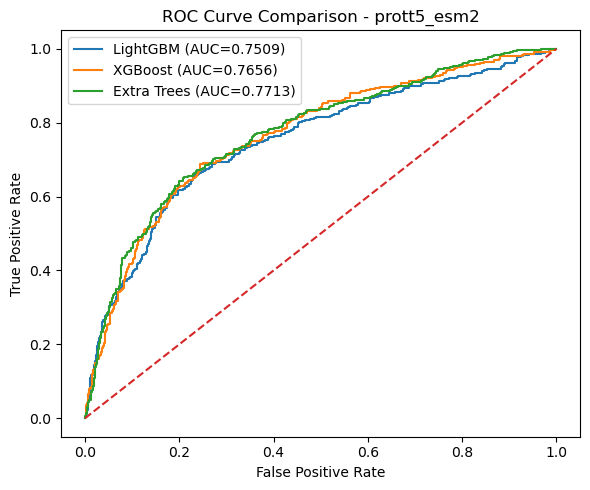

In [23]:
plt.figure(figsize=(6, 5))

fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_et, tpr_et, _ = roc_curve(y_test, y_prob_et)

plt.plot(fpr_lgbm, tpr_lgbm, label=f"LightGBM (AUC={roc_auc_score(y_test, y_prob_lgbm):.4f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.4f})")
plt.plot(fpr_et, tpr_et, label=f"Extra Trees (AUC={roc_auc_score(y_test, y_prob_et):.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve Comparison - {FEATURE_SET}")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{FEATURE_SET}_roc_comparison.png", dpi=300)
plt.show()

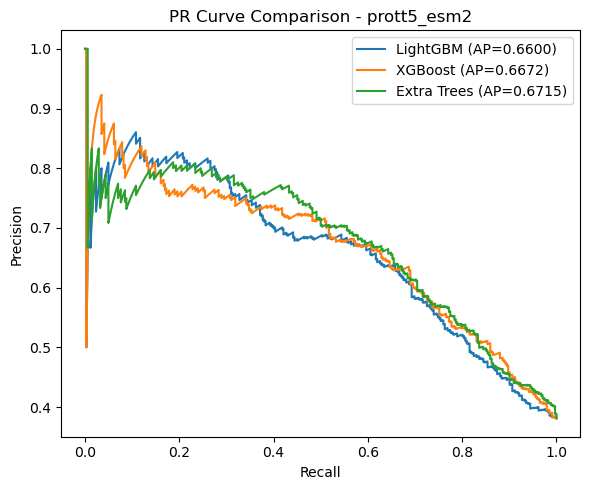

In [24]:
plt.figure(figsize=(6, 5))

precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_prob_lgbm)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
precision_et, recall_et, _ = precision_recall_curve(y_test, y_prob_et)

plt.plot(recall_lgbm, precision_lgbm, label=f"LightGBM (AP={average_precision_score(y_test, y_prob_lgbm):.4f})")
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (AP={average_precision_score(y_test, y_prob_xgb):.4f})")
plt.plot(recall_et, precision_et, label=f"Extra Trees (AP={average_precision_score(y_test, y_prob_et):.4f})")


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve Comparison - {FEATURE_SET}")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{FEATURE_SET}_pr_comparison.png", dpi=300)
plt.show()

In [25]:
joblib.dump(final_lgbm, MODELS_DIR / f"{FEATURE_SET}_lgbm.pkl")
joblib.dump(final_xgb, MODELS_DIR / f"{FEATURE_SET}_xgb.pkl")
joblib.dump(final_et, MODELS_DIR / f"{FEATURE_SET}_et.pkl")

['d:\\360Downloads\\bioinformatics\\Task\\AIP\\results\\models\\prott5_esm2_et.pkl']

## 4.调参

### （1）定义模型

In [ ]:
# 调参
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    random_state=42,
    n_jobs=-1
)

et_param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

In [ ]:
# 调参
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6, 8],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [1, 2, 5, 10],
    "scale_pos_weight": [1.0, scale_pos_weight, scale_pos_weight * 1.25]
}

In [ ]:
# 调参
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    random_state=42,
    n_jobs=-1
)

et_param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

In [322]:
# 调参
lgbm_result = tune_and_evaluate_model_no_threshold(
    model=lgbm_model,
    param_distributions=lgbm_param_dist,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="LightGBM",
    n_iter=20,
    cv_splits=5,
    scoring="average_precision",
    random_state=42
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 1365, number of negative: 2218
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043982 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21735
[LightGBM] [Info] Number of data points in the train set: 3583, number of used features: 1204
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.380966 -> initscore=-0.485451
[LightGBM] [Info] Start training from score -0.485451
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [323]:
xgb_result = tune_and_evaluate_model_no_threshold(
    model=xgb_model,
    param_distributions=xgb_param_dist,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="XGBoost",
    n_iter=20,
    cv_splits=5,
    scoring="average_precision",
    random_state=42
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

===== XGBoost Best Params =====
{'subsample': 1.0, 'scale_pos_weight': 2.031135531135531, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.6}
Best CV average_precision: 0.6819

===== XGBoost Independent Test @ threshold=0.5 =====
ACC: 0.7157
Precision: 0.6173
Recall: 0.6696
Specificity: 0.7441
F1: 0.6424
MCC: 0.4080
ROC_AUC: 0.7518
PR_AUC: 0.6611


In [324]:
et_result = tune_and_evaluate_model_no_threshold(
    model=et_model,
    param_distributions=et_param_dist,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Extra Trees",
    n_iter=20,
    cv_splits=5,
    scoring="average_precision",
    random_state=42
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

===== Extra Trees Best Params =====
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample'}
Best CV average_precision: 0.7027

===== Extra Trees Independent Test @ threshold=0.5 =====
ACC: 0.7570
Precision: 0.7109
Recall: 0.6111
Specificity: 0.8468
F1: 0.6572
MCC: 0.4739
ROC_AUC: 0.8180
PR_AUC: 0.7135


In [325]:
tuned_test_results_df = pd.DataFrame([
    {
        "model": "LightGBM",
        **lgbm_result["test_metrics"],
    },
    {
        "model": "XGBoost",
        **xgb_result["test_metrics"],
    },
    {
        "model": "Extra Trees",
        **et_result["test_metrics"],
    },
])

tuned_test_results_df

,model,ACC,Precision,Recall,Specificity,F1,MCC,ROC_AUC,PR_AUC
0,LightGBM,0.729097,0.682657,0.540936,0.845045,0.603589,0.408276,0.753124,0.665484
1,XGBoost,0.715719,0.617251,0.669591,0.744144,0.642356,0.408039,0.751836,0.661138
2,Extra Trees,0.756968,0.710884,0.611111,0.846847,0.657233,0.473863,0.818029,0.713541
